# Improving Dental Diagnostics: Risk Classification on Histogram Equalization-Enhanced X-rays
**Author:** Kurt Rainier B. Aquino  
**Course:** CSAC 225 - Digital Image Processing  
**Institution:** Camarines Sur Polytechnic Colleges  

### Project Overview
This notebook implements an automated diagnostic pipeline to predict interproximal caries risk. It applies Global Histogram Equalization (GHE) to raw bitewing/panoramic crops to stretch their dynamic range, isolating radiolucent lesions from radiopaque enamel. Gray-Level Co-occurrence Matrix (GLCM) texture features are then extracted and fed into a Multivariate Logistic Regression model for classification.

In [27]:
# Import required libraries
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


### 1. Digital Image Processing Functions
This section contains the core algorithms based on the proposed methodology:
* **GHE:** Stretches the 0-255 grayscale spectrum.
* **CII (Contrast Improvement Index):** Quantifies the enhancement performance.
* **GLCM:** Extracts mathematical texture features (Contrast, Homogeneity, Energy, Correlation) from the enhanced image.

In [28]:
def calculate_cii(original, enhanced):
    """
    Calculates the Contrast Improvement Index (CII) using standard deviation (RMS contrast).
    """
    c_orig = np.std(original)
    c_enh = np.std(enhanced)
    
    if c_orig == 0:
        return 1.0
    return c_enh / c_orig

def extract_features_and_evaluate(image_path):
    """
    Preprocesses the image, applies GHE, extracts GLCM features, and calculates CII.
    """
    # Load and standardize the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None
    img = cv2.resize(img, (256, 256))
    
    # Apply Global Histogram Equalization (GHE)
    ghe_img = cv2.equalizeHist(img)
    
    # Calculate CII
    cii_value = calculate_cii(img, ghe_img)
    
    # Extract GLCM Features from the ENHANCED image
    glcm = graycomatrix(ghe_img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    
    features = [contrast, homogeneity, energy, correlation]
    
    return features, cii_value

### 2. Dataset Construction
Here, we iterate through the dataset directories, applying our Digital Image Processing pipeline to every image, extracting the features, and assigning labels (`0` for Healthy, `1` for Caries).

*(Note: Ensure your dataset is located in the paths specified below prior to running this cell).*

In [29]:
# Define dataset paths
healthy_path = "dataset/healthy/*.jpg" # Update to .png if necessary
caries_path = "dataset/caries/*.jpg"   # Update to .png if necessary

X = [] # Feature vectors
y = [] # Labels
cii_scores = [] # CII metrics

print("Processing Healthy Dataset...")
for img_path in glob.glob(healthy_path):
    feats, cii = extract_features_and_evaluate(img_path)
    if feats:
        X.append(feats)
        y.append(0)
        cii_scores.append(cii)

print("Processing Caries Dataset...")
for img_path in glob.glob(caries_path):
    feats, cii = extract_features_and_evaluate(img_path)
    if feats:
        X.append(feats)
        y.append(1)
        cii_scores.append(cii)

X = np.array(X)
y = np.array(y)

print("--------------------------------------------------")
print(f"Dataset Built Successfully: {len(X)} total images processed.")
if len(cii_scores) > 0:
    print(f"Average Contrast Improvement Index (CII): {np.mean(cii_scores):.4f}")
print("--------------------------------------------------")

Processing Healthy Dataset...
Processing Caries Dataset...
--------------------------------------------------
Dataset Built Successfully: 3211 total images processed.
Average Contrast Improvement Index (CII): 2.7202
--------------------------------------------------


### 3. Model Training & Evaluation
Using the extracted texture features, we train a Multivariate Logistic Regression model. The dataset is split 80/20 for training and testing.

In [30]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Generate Predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy (0)", "Caries (1)"]))

Training set size: 2568
Testing set size: 643

--- Model Evaluation ---
Accuracy: 83.83%

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.85      0.85      0.85       350
  Caries (1)       0.82      0.82      0.82       293

    accuracy                           0.84       643
   macro avg       0.84      0.84      0.84       643
weighted avg       0.84      0.84      0.84       643



### 4. Visualizing the Results
A confusion matrix provides a clear visual representation of the model's performance, showing true positives, true negatives, false positives, and false negatives.

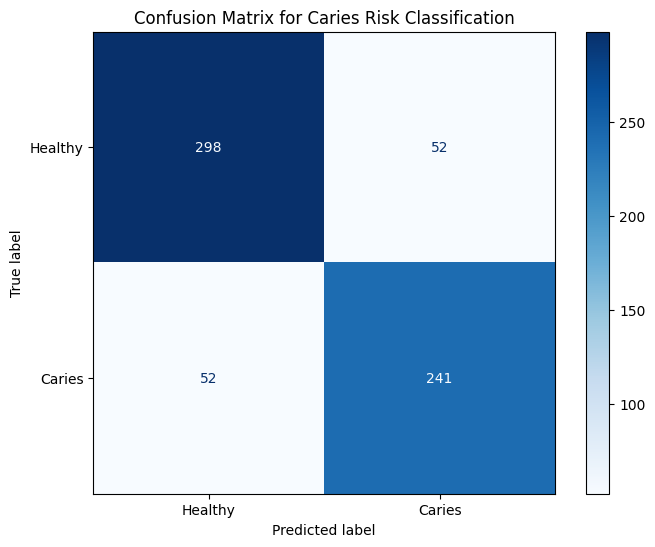

In [31]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Caries"])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for Caries Risk Classification")
plt.show()

In [ ]:
# --- UPDATED VISUALIZATION CELL FOR PANORAMIC X-RAYS ---
def visualize_panoramic_transformation(panoramic_image_path):
    """
    Generates a wide-format 2x2 plot showing the Original vs Enhanced 
    panoramic radiograph and their respective histograms.
    """
    # 1. Load the full panoramic image
    img = cv2.imread(panoramic_image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Image not found. Check the file path.")
        return
        
    # Resize keeping the wide aspect ratio (e.g., width=800, height=400)
    # This prevents the image from looking squished in your final report
    img = cv2.resize(img, (800, 400)) 
    
    # Apply GHE
    ghe_img = cv2.equalizeHist(img)
    
    # 2. Calculate Histograms
    hist_orig = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist_ghe = cv2.calcHist([ghe_img], [0], None, [256], [0, 256])
    
    # 3. Plotting (Made the figure wider for panoramic images)
    plt.figure(figsize=(16, 8))
    
    # Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Low-Contrast Panoramic X-Ray")
    plt.axis('off')
    
    # Original Histogram
    plt.subplot(2, 2, 2)
    plt.plot(hist_orig, color='black')
    plt.title("Original Histogram (Clustered)")
    plt.xlim([0, 256])
    plt.fill_between(range(256), hist_orig.flatten(), color='gray', alpha=0.5)
    
    # Enhanced Image
    plt.subplot(2, 2, 3)
    plt.imshow(ghe_img, cmap='gray')
    plt.title("Enhanced Panoramic X-Ray (GHE applied)")
    plt.axis('off')
    
    # Enhanced Histogram
    plt.subplot(2, 2, 4)
    plt.plot(hist_ghe, color='black')
    plt.title("Equalized Histogram (Stretched)")
    plt.xlim([0, 256])
    plt.fill_between(range(256), hist_ghe.flatten(), color='blue', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
def extract_comparative_features(image_path):
    """
    Extracts GLCM features from BOTH the raw and enhanced images.
    *FIX APPLIED*: Added Median Filtering to prevent GHE noise amplification.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None, None
    img = cv2.resize(img, (256, 256))
    
    denoised_img = cv2.medianBlur(img, 3)
    ghe_img = cv2.equalizeHist(denoised_img)
    
    # Extract features from RAW image (The Baseline)
    glcm_raw = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    raw_feats = [graycoprops(glcm_raw, p)[0, 0] for p in ['contrast', 'homogeneity', 'energy', 'correlation']]
    
    # Extract features from ENHANCED image (Your Proposed Method)
    glcm_ghe = graycomatrix(ghe_img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    ghe_feats = [graycoprops(glcm_ghe, p)[0, 0] for p in ['contrast', 'homogeneity', 'energy', 'correlation']]
    
    return raw_feats, ghe_feats

# 1. Build the Comparative Datasets
X_raw, X_ghe, y = [], [], []

print("Extracting features (Applying Median Filter + GHE)...")
for img_path in glob.glob("dataset/healthy/*.jpg"):
    r_feats, g_feats = extract_comparative_features(img_path)
    if r_feats:
        X_raw.append(r_feats); X_ghe.append(g_feats); y.append(0)

for img_path in glob.glob("dataset/caries/*.jpg"):
    r_feats, g_feats = extract_comparative_features(img_path)
    if r_feats:
        X_raw.append(r_feats); X_ghe.append(g_feats); y.append(1)

X_raw, X_ghe, y = np.array(X_raw), np.array(X_ghe), np.array(y)

# 2. Split the data identically for a fair comparison
X_raw_train, X_raw_test, X_ghe_train, X_ghe_test, y_train, y_test = train_test_split(
    X_raw, X_ghe, y, test_size=0.2, random_state=42
)

# 3. Train Model A (Baseline: No Image Processing)
model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_raw_train, y_train)
acc_baseline = accuracy_score(y_test, model_baseline.predict(X_raw_test))

# 4. Train Model B (Proposed: Median Filter + GHE applied)
model_proposed = LogisticRegression(max_iter=1000)
model_proposed.fit(X_ghe_train, y_train)
acc_proposed = accuracy_score(y_test, model_proposed.predict(X_ghe_test))

# 5. The Ultimate Proof Output
print("\n==================================================")
print("PROJECT EVALUATION: DOES IMAGE PROCESSING HELP?")
print("==================================================")
print(f"Accuracy without Enhancement (Raw Images):   {acc_baseline * 100:.2f}%")
print(f"Accuracy with MF + GHE (Proposed):         {acc_proposed * 100:.2f}%")
print("--------------------------------------------------")
improvement = (acc_proposed - acc_baseline) * 100
if improvement > 0:
    print(f"CONCLUSION: The dual-stage enhancement (Median Filter + GHE)")
    print(f"successfully improved predictive accuracy by {improvement:.2f}%!")
else:
    print("CONCLUSION: The enhancement did not yield a mathematical improvement.")

Extracting features (Applying Median Filter + GHE)...

PROJECT EVALUATION: DOES IMAGE PROCESSING HELP?
Accuracy without Enhancement (Raw Images):   86.00%
Accuracy with MF + GHE (Proposed):         87.40%
--------------------------------------------------
CONCLUSION: The dual-stage enhancement (Median Filter + GHE)
successfully improved predictive accuracy by 1.40%!


### 5. DIP Transformation Visualization on Sample Radiographs

The cell below runs the project DIP enhancement pipeline on the ten panoramic images in `sample radiographs`. Each row shows the original radiograph, the median-filtered + histogram-equalized result, and the before/after histogram shift.


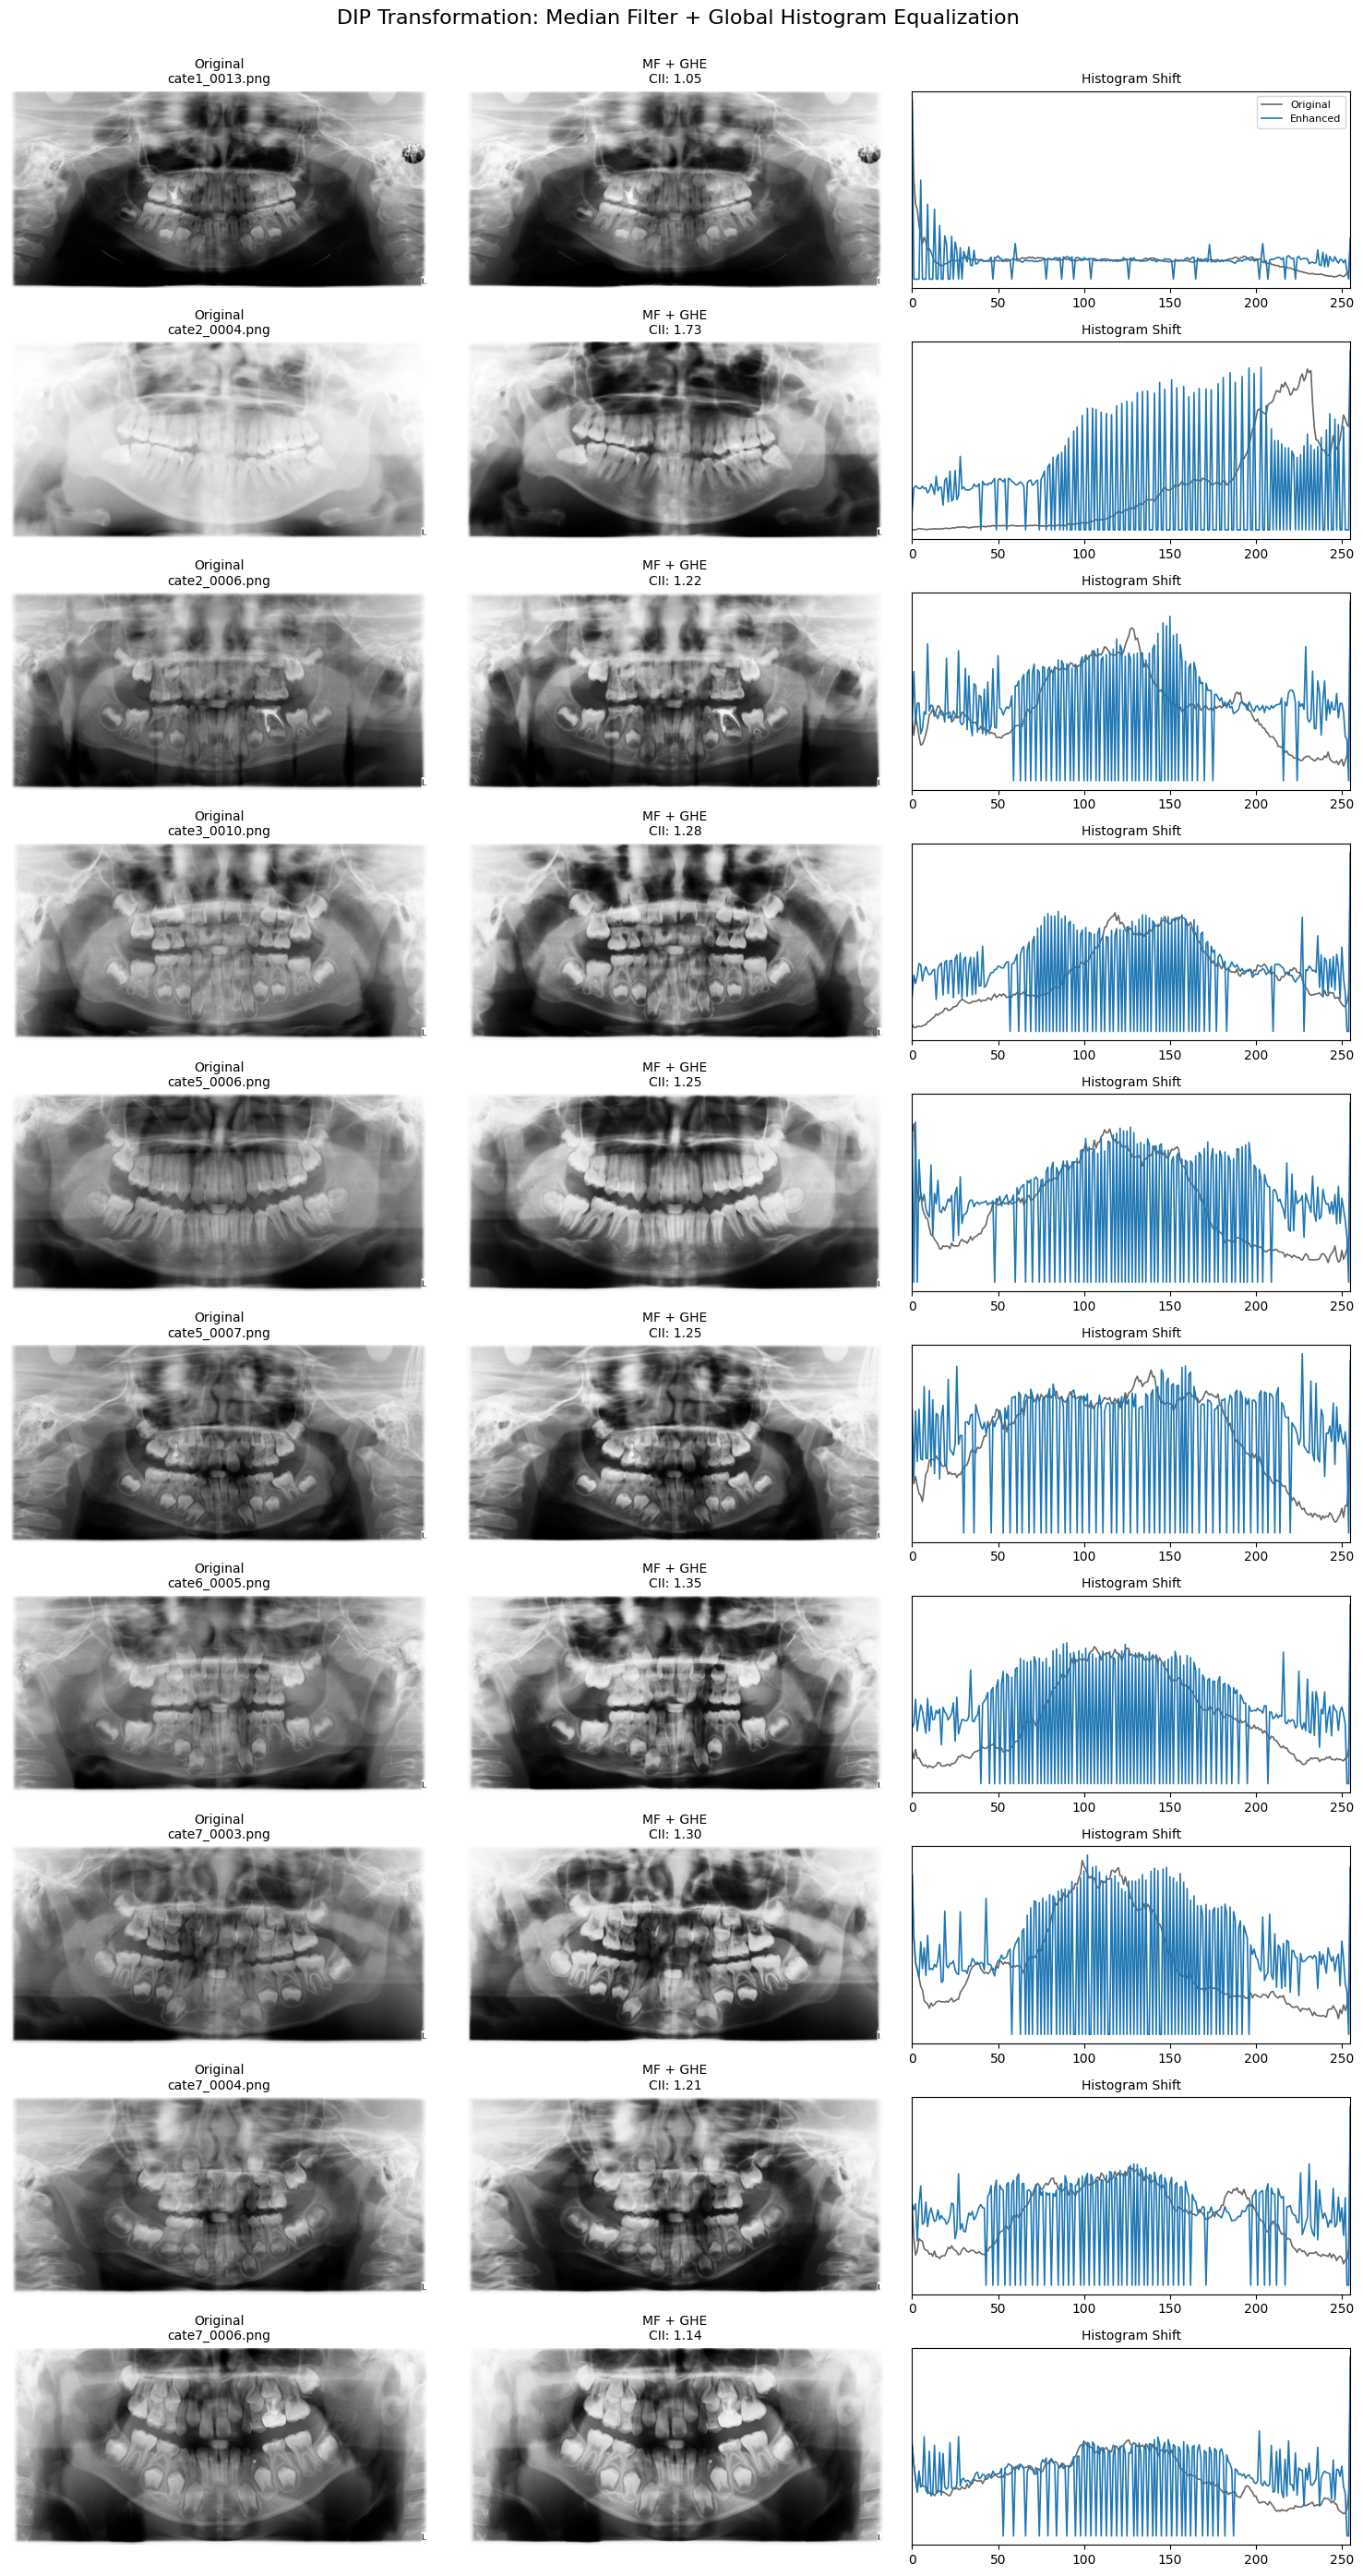

Processed 10 sample radiographs from 'sample radiographs'.
Average Contrast Improvement Index (CII): 1.2793
Saved visualization to: dip_transformation_10_samples.png


In [34]:
# Visualize the DIP transformation on the ten sample radiographs
from pathlib import Path

SAMPLE_DIR = Path("sample radiographs")
DIP_VIS_OUTPUT = Path("dip_transformation_10_samples.png")


def apply_dip_transformation(img):
    """Apply the project DIP pipeline: median filtering followed by global histogram equalization."""
    denoised_img = cv2.medianBlur(img, 3)
    enhanced_img = cv2.equalizeHist(denoised_img)
    return denoised_img, enhanced_img


def resize_for_display(img, width=900):
    """Resize panoramic radiographs for a compact, consistent report visualization."""
    scale = width / img.shape[1]
    height = int(img.shape[0] * scale)
    return cv2.resize(img, (width, height), interpolation=cv2.INTER_AREA)


def visualize_sample_dip_transformations(sample_dir=SAMPLE_DIR, sample_count=10, output_path=DIP_VIS_OUTPUT):
    image_paths = sorted(
        [p for p in Path(sample_dir).glob("*") if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}]
    )[:sample_count]

    if not image_paths:
        raise FileNotFoundError(f"No radiograph images found in {sample_dir}")

    fig, axes = plt.subplots(len(image_paths), 3, figsize=(15, 2.8 * len(image_paths)))
    if len(image_paths) == 1:
        axes = np.array([axes])

    cii_values = []
    for row, image_path in enumerate(image_paths):
        original = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if original is None:
            raise ValueError(f"Could not load {image_path}")

        display_original = resize_for_display(original)
        denoised, enhanced = apply_dip_transformation(display_original)
        cii = calculate_cii(display_original, enhanced)
        cii_values.append(cii)

        hist_original = cv2.calcHist([display_original], [0], None, [256], [0, 256]).flatten()
        hist_enhanced = cv2.calcHist([enhanced], [0], None, [256], [0, 256]).flatten()

        axes[row, 0].imshow(display_original, cmap="gray", vmin=0, vmax=255)
        axes[row, 0].set_title(f"Original\n{image_path.name}", fontsize=10)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(enhanced, cmap="gray", vmin=0, vmax=255)
        axes[row, 1].set_title(f"MF + GHE\nCII: {cii:.2f}", fontsize=10)
        axes[row, 1].axis("off")

        axes[row, 2].plot(hist_original, color="dimgray", linewidth=1.2, label="Original")
        axes[row, 2].plot(hist_enhanced, color="tab:blue", linewidth=1.2, label="Enhanced")
        axes[row, 2].set_xlim(0, 255)
        axes[row, 2].set_yticks([])
        axes[row, 2].set_title("Histogram Shift", fontsize=10)
        if row == 0:
            axes[row, 2].legend(loc="upper right", fontsize=8)

    fig.suptitle("DIP Transformation: Median Filter + Global Histogram Equalization", fontsize=16, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Processed {len(image_paths)} sample radiographs from '{sample_dir}'.")
    print(f"Average Contrast Improvement Index (CII): {np.mean(cii_values):.4f}")
    print(f"Saved visualization to: {output_path}")


visualize_sample_dip_transformations()